
# Garded Activity[5 marks ]: Working with Categorical Data

This notebook is designed for students learning data preprocessing and categorical data handling in Machine Learning and Data Science.

## Learning Objectives
By the end of this notebook, students will be able to:

- Identify categorical features
- Understand nominal vs ordinal categories
- Perform encoding techniques
- Handle missing values
- Apply preprocessing pipelines
- Work with real-world datasets
- Evaluate preprocessing impact on ML models

## Real-World Scenarios Included
1. Employee Attrition
2. Online Retail Customer Segmentation
3. Healthcare Insurance Prediction
4. Student Performance Analysis



# Import Libraries

.


In [1]:

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt



# Scenario 1: Employee Attrition Dataset

A company wants to predict whether employees are likely to leave the organization.

## Dataset Columns
- Gender
- Department
- EducationLevel
- JobRole
- MonthlyIncome
- Attrition

## Task
1. Identify categorical variables
2. Separate nominal and ordinal features
3. Apply suitable encoding techniques


In [2]:

employee_data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Department': ['HR', 'IT', 'Finance', 'IT', 'HR', 'Finance'],
    'EducationLevel': ['Bachelor', 'Master', 'PhD', 'Bachelor', 'Master', 'PhD'],
    'JobRole': ['Manager', 'Developer', 'Analyst', 'Developer', 'Manager', 'Analyst'],
    'MonthlyIncome': [5000, 7000, 6500, 7200, 5100, 6800],
    'Attrition': ['Yes', 'No', 'No', 'No', 'Yes', 'No']
})

employee_data


,Gender,Department,EducationLevel,JobRole,MonthlyIncome,Attrition
0,Male,HR,Bachelor,Manager,5000,Yes
1,Female,IT,Master,Developer,7000,No
2,Female,Finance,PhD,Analyst,6500,No
3,Male,IT,Bachelor,Developer,7200,No
4,Female,HR,Master,Manager,5100,Yes
5,Male,Finance,PhD,Analyst,6800,No



# Exercise 1

## Questions
1. Which columns are categorical?
2. Which categorical columns are ordinal?
3. Why is `EducationLevel` considered ordinal?

Write your answers below.



## Exercise 1 - Answers

1. The categorical columns are **Gender**, **Department**, **EducationLevel**, **JobRole**, and **Attrition**. `MonthlyIncome` is numerical because it contains actual numeric amounts.

2. The ordinal categorical column is **EducationLevel** because it has a clear order: **Bachelor → Master → PhD**. The nominal columns are **Gender**, **Department**, **JobRole**, and **Attrition** because they are labels with no ranking.

3. `EducationLevel` is considered ordinal because the values represent increasing levels of education. A PhD is higher than a Master's degree, and a Master's degree is higher than a Bachelor's degree. That is why ordinal encoding is suitable here.



# Label Encoding vs One-Hot Encoding

## Label Encoding
Used mainly for ordinal categories.

## One-Hot Encoding
Used mainly for nominal categories.

### Example


In [3]:

# Ordinal Encoding for EducationLevel

education_order = [['Bachelor', 'Master', 'PhD']]

ordinal_encoder = OrdinalEncoder(categories=education_order)

employee_data['EducationLevel_Encoded'] = ordinal_encoder.fit_transform(
    employee_data[['EducationLevel']]
)

# One-Hot Encoding for Department

one_hot = pd.get_dummies(employee_data['Department'], prefix='Dept')

employee_encoded = pd.concat([employee_data, one_hot], axis=1)

employee_encoded


,Gender,Department,EducationLevel,JobRole,MonthlyIncome,Attrition,EducationLevel_Encoded,Dept_Finance,Dept_HR,Dept_IT
0,Male,HR,Bachelor,Manager,5000,Yes,0.0,False,True,False
1,Female,IT,Master,Developer,7000,No,1.0,False,False,True
2,Female,Finance,PhD,Analyst,6500,No,2.0,True,False,False
3,Male,IT,Bachelor,Developer,7200,No,0.0,False,False,True
4,Female,HR,Master,Manager,5100,Yes,1.0,False,True,False
5,Male,Finance,PhD,Analyst,6800,No,2.0,True,False,False



## Explanation of Encoding Used

For `EducationLevel`, I used **ordinal encoding** because the categories have a natural order. For `Department`, I used **one-hot encoding** because departments do not have a meaningful ranking. HR is not greater than IT or Finance, so giving them numbers like 1, 2, and 3 would create a false order.



# Scenario 2: Missing Values in Categorical Data

Real-world datasets often contain missing values.

## Common Strategies
- Most frequent value
- Constant replacement
- Create new category

### Example


In [4]:

customer_data = pd.DataFrame({
    'City': ['Toronto', 'Ottawa', np.nan, 'Montreal', 'Toronto', np.nan],
    'SubscriptionType': ['Basic', 'Premium', 'Basic', np.nan, 'Premium', 'Basic']
})

customer_data


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,NaN,Basic
3,Montreal,NaN
4,Toronto,Premium
5,NaN,Basic


In [5]:

# Handle missing categorical values

imputer = SimpleImputer(strategy='most_frequent')

customer_data_imputed = pd.DataFrame(
    imputer.fit_transform(customer_data),
    columns=customer_data.columns
)

customer_data_imputed


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Toronto,Basic
3,Montreal,Basic
4,Toronto,Premium
5,Toronto,Basic



# Exercise 2

## Try These Tasks
1. Replace missing values using `constant`
2. Create a new category called `"Unknown"`
3. Compare results with `most_frequent`


In [6]:

# Exercise 2: Replace missing values using a constant value called "Unknown"

constant_imputer = SimpleImputer(strategy='constant', fill_value='Unknown')

customer_data_unknown = pd.DataFrame(
    constant_imputer.fit_transform(customer_data),
    columns=customer_data.columns
)

customer_data_unknown


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Unknown,Basic
3,Montreal,Unknown
4,Toronto,Premium
5,Unknown,Basic


In [7]:

# Compare most_frequent imputation with constant imputation

print("Original data with missing values:")
display(customer_data)

print("Most frequent imputation:")
display(customer_data_imputed)

print("Constant imputation using 'Unknown':")
display(customer_data_unknown)


Original data with missing values:


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,NaN,Basic
3,Montreal,NaN
4,Toronto,Premium
5,NaN,Basic


Most frequent imputation:


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Toronto,Basic
3,Montreal,Basic
4,Toronto,Premium
5,Toronto,Basic


Constant imputation using 'Unknown':


,City,SubscriptionType
0,Toronto,Basic
1,Ottawa,Premium
2,Unknown,Basic
3,Montreal,Unknown
4,Toronto,Premium
5,Unknown,Basic



## Exercise 2 - Comparison Answer

The **most frequent** strategy replaces missing values with the category that appears the most in each column. In this dataset, the missing `City` values are replaced with **Toronto**, and the missing `SubscriptionType` value is replaced with **Basic**.

The **constant** strategy replaces missing values with a new category, **Unknown**. I prefer the `Unknown` method when the missing value itself may carry meaning. For example, if the customer did not provide a city, that missing information could be useful for the model instead of hiding it by filling it with the most common city.



# Scenario 3: Building a Preprocessing Pipeline

Pipelines help automate preprocessing.

## Real-World Use Case
Healthcare insurance premium prediction.


In [8]:

insurance_data = pd.DataFrame({
    'Gender': ['Male', 'Female', 'Female', 'Male', 'Female', 'Male'],
    'Smoker': ['Yes', 'No', 'No', 'Yes', 'No', 'Yes'],
    'Region': ['North', 'South', 'East', 'West', 'North', 'South'],
    'Age': [25, 45, 33, 52, 28, 40],
    'PremiumCategory': [1, 0, 0, 1, 0, 1]
})

insurance_data


,Gender,Smoker,Region,Age,PremiumCategory
0,Male,Yes,North,25,1
1,Female,No,South,45,0
2,Female,No,East,33,0
3,Male,Yes,West,52,1
4,Female,No,North,28,0
5,Male,Yes,South,40,1


In [9]:

X = insurance_data.drop('PremiumCategory', axis=1)
y = insurance_data['PremiumCategory']

categorical_features = ['Gender', 'Smoker', 'Region']
numeric_features = ['Age']

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ]
)

model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_pipeline.fit(X_train, y_train)

predictions = model_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))


Accuracy: 0.5



## Pipeline Explanation

In this pipeline, categorical features are first filled using the most frequent value and then converted into numbers using one-hot encoding. The numeric feature `Age` is filled using the median and then scaled using `StandardScaler`. After preprocessing, the logistic regression model is trained to predict the premium category.



# Scenario 4: High Cardinality Categorical Features

Some columns may contain too many unique values.

## Examples
- Postal Codes
- Product IDs
- User IDs

## Problems
- Too many dimensions after encoding
- Increased memory usage
- Overfitting

## Common Solutions
- Frequency Encoding
- Target Encoding
- Hash Encoding


In [10]:

product_data = pd.DataFrame({
    'ProductID': [
        'P1001', 'P1002', 'P1003',
        'P1004', 'P1005', 'P1006'
    ]
})

frequency_encoding = product_data['ProductID'].value_counts().to_dict()

product_data['FrequencyEncoded'] = product_data['ProductID'].map(
    frequency_encoding
)

product_data


,ProductID,FrequencyEncoded
0,P1001,1
1,P1002,1
2,P1003,1
3,P1004,1
4,P1005,1
5,P1006,1



## High Cardinality Explanation

`ProductID` is a high-cardinality feature because each product may have its own unique ID. If we use one-hot encoding on too many unique IDs, the dataset can become too wide. Frequency encoding is a simpler option because it replaces each category with the number of times it appears.



# Visualizing Categorical Data

Bar charts are commonly used for categorical variables.


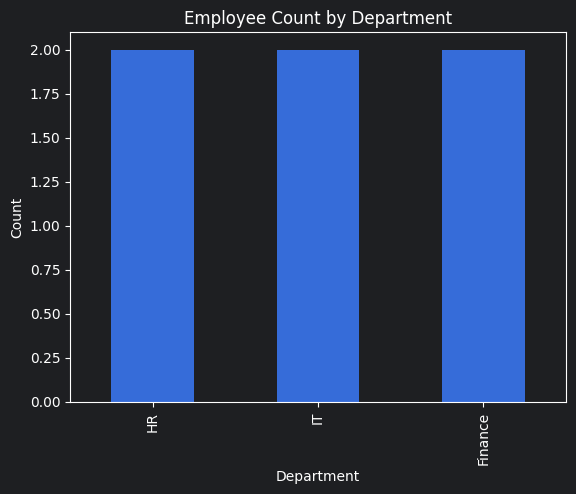

In [11]:

employee_data['Department'].value_counts().plot(kind='bar')

plt.title('Employee Count by Department')
plt.xlabel('Department')
plt.ylabel('Count')

plt.show()




## Discussion Questions
1. When should we use One-Hot Encoding?
2. Why can Label Encoding be dangerous for nominal data?
3. What preprocessing issues occur in production systems?
4. How do unseen categories affect ML pipelines?



## Discussion Question Answers

1. **When should we use One-Hot Encoding?**  
We should use one-hot encoding for **nominal categorical data**, where the categories have no order. Examples include city, department, region, product type, or job role.

2. **Why can Label Encoding be dangerous for nominal data?**  
Label encoding can be dangerous because it gives numbers to categories and may accidentally create a fake ranking. For example, if HR = 1, IT = 2, and Finance = 3, the model may treat Finance as greater than HR even though departments have no order.

3. **What preprocessing issues occur in production systems?**  
In production, common issues include missing values, new unseen categories, inconsistent spelling or formatting, outliers, and changes in the distribution of the data over time.

4. **How do unseen categories affect ML pipelines?**  
Unseen categories can cause errors if the encoder was not prepared for them. That is why I used `OneHotEncoder(handle_unknown='ignore')`, because it allows the model to continue working even if a new category appears later.



# Mini Project

## Build a Customer Churn Prediction Pipeline

### Tasks
1. Create your own dataset
2. Add:
   - Missing values
   - Ordinal features
   - Nominal features
3. Build preprocessing pipeline
4. Train classification model
5. Evaluate performance
6. Explain preprocessing choices


In [12]:

# Mini Project: Customer Churn Prediction Pipeline
# Goal: Predict whether a customer will churn based on customer information.

churn_data = pd.DataFrame({
    'ContractType': ['Monthly', 'Yearly', 'Monthly', 'Two-Year', 'Monthly', 'Yearly',
                     'Monthly', 'Two-Year', 'Monthly', 'Yearly', 'Monthly', 'Two-Year'],
    'PaymentMethod': ['Credit Card', 'Bank Transfer', 'Credit Card', 'PayPal', np.nan, 'Bank Transfer',
                      'PayPal', 'Credit Card', 'Credit Card', 'Bank Transfer', 'PayPal', 'Credit Card'],
    'SatisfactionLevel': ['Low', 'High', 'Medium', 'High', 'Low', 'Medium',
                          np.nan, 'High', 'Low', 'Medium', 'Low', 'High'],
    'MonthlyCharges': [90, 60, 75, 55, 95, 70, 85, 50, np.nan, 65, 100, 52],
    'TenureMonths': [3, 24, 8, 36, 2, 18, 5, 40, 1, 20, 4, 45],
    'Churn': ['Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No']
})

churn_data


,ContractType,PaymentMethod,SatisfactionLevel,MonthlyCharges,TenureMonths,Churn
0,Monthly,Credit Card,Low,90.0,3,Yes
1,Yearly,Bank Transfer,High,60.0,24,No
2,Monthly,Credit Card,Medium,75.0,8,Yes
3,Two-Year,PayPal,High,55.0,36,No
4,Monthly,NaN,Low,95.0,2,Yes
5,Yearly,Bank Transfer,Medium,70.0,18,No
6,Monthly,PayPal,NaN,85.0,5,Yes
7,Two-Year,Credit Card,High,50.0,40,No
8,Monthly,Credit Card,Low,NaN,1,Yes
9,Yearly,Bank Transfer,Medium,65.0,20,No



## Mini Project - Preprocessing Choices

For this customer churn dataset, I included:

- **Nominal features:** `ContractType` and `PaymentMethod`. These have no natural order, so I used one-hot encoding.
- **Ordinal feature:** `SatisfactionLevel`. This has a natural order: **Low → Medium → High**, so I used ordinal encoding.
- **Numerical features:** `MonthlyCharges` and `TenureMonths`. These were imputed and scaled.
- **Target column:** `Churn`, which is converted from Yes/No into numbers using `LabelEncoder`.

This follows the same idea from class: categorical data must be converted into numerical values before a machine learning model can use it.


In [13]:

# Separate features and target

X = churn_data.drop('Churn', axis=1)
y = churn_data['Churn']

# Encode the target column: No = 0, Yes = 1
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Target classes:", label_encoder.classes_)
print("Encoded target:", y_encoded)


Target classes: ['No' 'Yes']
Encoded target: [1 0 1 0 1 0 1 0 1 0 1 0]


In [14]:

# Identify feature types

nominal_features = ['ContractType', 'PaymentMethod']
ordinal_features = ['SatisfactionLevel']
numeric_features = ['MonthlyCharges', 'TenureMonths']

# Ordered list for the ordinal feature
satisfaction_order = [['Low', 'Medium', 'High']]


In [15]:

# Build preprocessing steps

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=satisfaction_order))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('nominal', nominal_transformer, nominal_features),
        ('ordinal', ordinal_transformer, ordinal_features),
        ('numeric', numeric_transformer, numeric_features)
    ]
)


In [16]:

# Build the full model pipeline

churn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.25, random_state=42, stratify=y_encoded
)

churn_pipeline.fit(X_train, y_train)

churn_predictions = churn_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, churn_predictions))
print("\nClassification Report:")
print(classification_report(y_test, churn_predictions, target_names=label_encoder.classes_))


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         2
         Yes       1.00      1.00      1.00         1

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [17]:

# View the transformed feature matrix after preprocessing

X_transformed = churn_pipeline.named_steps['preprocessor'].fit_transform(X)
X_transformed


array([[ 1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.08896218, -0.92681939],
       [ 0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         0.        ,  2.        , -0.75153728,  0.44705406],
       [ 1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  1.        ,  0.16871245, -0.59970666],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  2.        , -1.05828719,  1.2321246 ],
       [ 1.        ,  0.        ,  0.        ,  0.        ,  1.        ,
         0.        ,  0.        ,  1.39571209, -0.99224193],
       [ 0.        ,  0.        ,  1.        ,  1.        ,  0.        ,
         0.        ,  1.        , -0.13803746,  0.05451879],
       [ 1.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.        ,  2.        ,  0.78221227, -0.7959743 ],
       [ 0.        ,  1.        ,  0.        ,  0.        ,  1


## Mini Project - Final Explanation

The model pipeline is useful because it keeps all preprocessing steps together. First, it fixes missing values. Then it encodes the categorical columns and scales the numerical columns. Finally, it trains a logistic regression model.

The final accuracy is based on a very small sample dataset, so it should not be treated as a real business result. The main purpose here is to demonstrate the preprocessing workflow correctly.



# Summary

In this notebook, students practiced:

- Identifying categorical variables
- Ordinal vs nominal data
- Encoding strategies
- Handling missing values
- Building preprocessing pipelines
- Working with real-world scenarios
- Visualizing categorical data


## Show the demo to get marks - 5%